# Parte 1
Verificación visual. 

In [1]:
pts = [(0, -5), (1, -4), (2, 3)]

In [2]:
def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

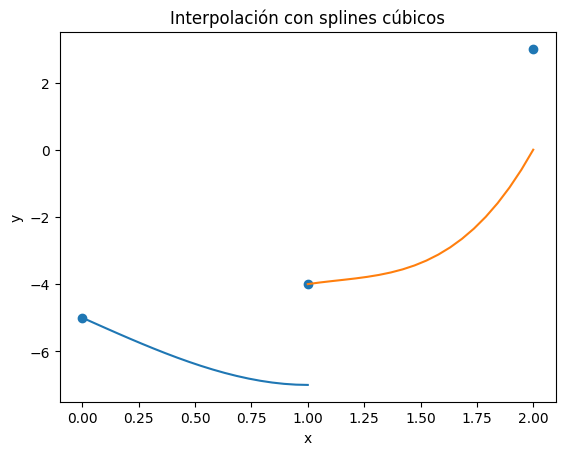

In [12]:
s = [
    {"a": -5, "b": -3, "c": 0, "d": 1},
    {"a": -4, "b": 1, "c": -2, "d": 5},
]


dibujar_spline(pts, s)

# Parte 2
Completar código para definir la función Spline.

In [1]:
import sympy as sym
from IPython.display import display


# ###################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation ``S``. Every two points are interpolated by a cubic polynomial
    ``S_j`` of the form ``S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.``

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  # sort points by x

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines

    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between  contiguous xs

    # alpha = # completar
    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z  # = completar

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])
        a  # = completar
        print(j, a, b, c[j], d)
        S  # = completar

        splines.append(S)
    splines.reverse()
    return splines

In [3]:
xs = [0, 1, 2]
ys = [-5, -4, 3]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("______")
_ = [display(s.expand()) for s in splines]

1 -4 4.0 4.5 -1.5
0 -5 -0.5 0.0 1.5


4.0*x - 1.5*(x - 1)**3 + 4.5*(x - 1)**2 - 8.0

1.5*x**3 - 0.5*x - 5

______


-1.5*x**3 + 9.0*x**2 - 9.5*x - 2.0

1.5*x**3 - 0.5*x - 5